# Лабораторная работа 4. PI calc



**Цель работы:** реализовать алгоритм вычисления числа Pi методом Монте-Карло, а затем сравнить время выполнения и точность результатов. Дополнительно провести запуски для разных значений N , рассчитать ускорение GPU и погрешность, построить графики.

In [1]:
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PI_REF = np.pi
N_values = [10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]
repeats = 3

## Распараллеливание

В GPU-версии точки распределяются между CUDA-потоками. Каждый поток обрабатывает свою часть точек: генерирует координаты, проверяет условие `x² + y² <= 1` и считает количество попаданий. После этого результаты потоков суммируются внутри блоков, а затем объединяются в общий результат.

In [2]:
%%writefile pi_monte_carlo.cu
#include <cuda_runtime.h>
#include <curand_kernel.h>

#include <chrono>
#include <cmath>
#include <cstdint>
#include <cstdlib>
#include <iomanip>
#include <iostream>
#include <random>
#include <string>

#define CHECK_CUDA(call)                                                        \
    do {                                                                        \
        cudaError_t err = (call);                                                \
        if (err != cudaSuccess) {                                                \
            std::cerr << "CUDA error: " << cudaGetErrorString(err)              \
                      << " at " << __FILE__ << ":" << __LINE__ << std::endl;   \
            std::exit(EXIT_FAILURE);                                             \
        }                                                                       \
    } while (0)

struct CpuResult {
    double pi;
    double time_ms;
};

struct GpuResult {
    double pi;
    float time_ms;
};

__global__ void setupCurandKernel(curandState_t* states,
                                  unsigned long long seed,
                                  int total_threads) {
    int tid = blockIdx.x * blockDim.x + threadIdx.x;
    if (tid < total_threads) {
        curand_init(seed, tid, 0, &states[tid]);
    }
}

__global__ void piMonteCarloKernel(curandState_t* states,
                                   unsigned long long* block_counts,
                                   unsigned long long N) {
    extern __shared__ unsigned int shared_counts[];

    int local_tid = threadIdx.x;
    int global_tid = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = gridDim.x * blockDim.x;

    curandState_t local_state = states[global_tid];
    unsigned int local_count = 0;

    for (unsigned long long i = static_cast<unsigned long long>(global_tid); i < N; i += stride) {
        float x = curand_uniform(&local_state);
        float y = curand_uniform(&local_state);
        if (x * x + y * y < 1.0f) {
            local_count++;
        }
    }

    states[global_tid] = local_state;
    shared_counts[local_tid] = local_count;
    __syncthreads();

    for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (local_tid < s) {
            shared_counts[local_tid] += shared_counts[local_tid + s];
        }
        __syncthreads();
    }

    if (local_tid == 0) {
        block_counts[blockIdx.x] = static_cast<unsigned long long>(shared_counts[0]);
    }
}

__global__ void reduceKernel(const unsigned long long* input,
                             unsigned long long* output,
                             int n) {
    extern __shared__ unsigned long long sdata[];

    unsigned int tid = threadIdx.x;
    unsigned int i = blockIdx.x * (blockDim.x * 2) + threadIdx.x;

    unsigned long long sum = 0ULL;
    if (i < static_cast<unsigned int>(n)) {
        sum += input[i];
    }
    if (i + blockDim.x < static_cast<unsigned int>(n)) {
        sum += input[i + blockDim.x];
    }

    sdata[tid] = sum;
    __syncthreads();

    for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (tid < s) {
            sdata[tid] += sdata[tid + s];
        }
        __syncthreads();
    }

    if (tid == 0) {
        output[blockIdx.x] = sdata[0];
    }
}

CpuResult computePiCpu(unsigned long long N, unsigned long long seed) {
    std::mt19937_64 rng(seed);
    std::uniform_real_distribution<double> dist(0.0, 1.0);

    auto start = std::chrono::high_resolution_clock::now();

    unsigned long long inside = 0ULL;
    for (unsigned long long i = 0; i < N; ++i) {
        double x = dist(rng);
        double y = dist(rng);
        if (x * x + y * y < 1.0) {
            inside++;
        }
    }

    auto finish = std::chrono::high_resolution_clock::now();
    double time_ms = std::chrono::duration<double, std::milli>(finish - start).count();
    double pi = 4.0 * static_cast<double>(inside) / static_cast<double>(N);

    return {pi, time_ms};
}

GpuResult computePiGpu(unsigned long long N, unsigned long long seed) {
    const int block_size = 256;
    const int max_blocks = 1024;

    int blocks = static_cast<int>((N + block_size - 1ULL) / block_size);
    if (blocks < 1) blocks = 1;
    if (blocks > max_blocks) blocks = max_blocks;

    int total_threads = blocks * block_size;

    curandState_t* d_states = nullptr;
    unsigned long long* d_block_counts = nullptr;
    unsigned long long* d_reduce_temp = nullptr;

    CHECK_CUDA(cudaMalloc(&d_states, static_cast<size_t>(total_threads) * sizeof(curandState_t)));
    CHECK_CUDA(cudaMalloc(&d_block_counts, static_cast<size_t>(blocks) * sizeof(unsigned long long)));
    CHECK_CUDA(cudaMalloc(&d_reduce_temp, static_cast<size_t>(blocks) * sizeof(unsigned long long)));

    cudaEvent_t start_event, stop_event;
    CHECK_CUDA(cudaEventCreate(&start_event));
    CHECK_CUDA(cudaEventCreate(&stop_event));

    CHECK_CUDA(cudaEventRecord(start_event));

    setupCurandKernel<<<blocks, block_size>>>(d_states, seed, total_threads);
    CHECK_CUDA(cudaGetLastError());

    piMonteCarloKernel<<<blocks, block_size, block_size * sizeof(unsigned int)>>>(
        d_states, d_block_counts, N
    );
    CHECK_CUDA(cudaGetLastError());

    int current_n = blocks;
    unsigned long long* d_in = d_block_counts;
    unsigned long long* d_out = d_reduce_temp;

    while (current_n > 1) {
        int reduce_blocks = (current_n + block_size * 2 - 1) / (block_size * 2);
        reduceKernel<<<reduce_blocks, block_size, block_size * sizeof(unsigned long long)>>>(
            d_in, d_out, current_n
        );
        CHECK_CUDA(cudaGetLastError());

        current_n = reduce_blocks;
        unsigned long long* tmp = d_in;
        d_in = d_out;
        d_out = tmp;
    }

    CHECK_CUDA(cudaEventRecord(stop_event));
    CHECK_CUDA(cudaEventSynchronize(stop_event));

    float time_ms = 0.0f;
    CHECK_CUDA(cudaEventElapsedTime(&time_ms, start_event, stop_event));

    unsigned long long inside = 0ULL;
    CHECK_CUDA(cudaMemcpy(&inside, d_in, sizeof(unsigned long long), cudaMemcpyDeviceToHost));

    double pi = 4.0 * static_cast<double>(inside) / static_cast<double>(N);

    CHECK_CUDA(cudaEventDestroy(start_event));
    CHECK_CUDA(cudaEventDestroy(stop_event));
    CHECK_CUDA(cudaFree(d_states));
    CHECK_CUDA(cudaFree(d_block_counts));
    CHECK_CUDA(cudaFree(d_reduce_temp));

    return {pi, time_ms};
}

int main(int argc, char** argv) {
    if (argc < 2) {
        std::cerr << "Usage: " << argv[0] << " <N> [--csv] [--seed <seed>]" << std::endl;
        return EXIT_FAILURE;
    }

    unsigned long long N = std::stoull(argv[1]);
    unsigned long long seed = 12345ULL;
    bool csv = false;

    for (int i = 2; i < argc; ++i) {
        std::string arg = argv[i];
        if (arg == "--csv") {
            csv = true;
        } else if (arg == "--seed" && i + 1 < argc) {
            seed = std::stoull(argv[++i]);
        }
    }

    CpuResult cpu = computePiCpu(N, seed);
    GpuResult gpu = computePiGpu(N, seed);

    const double pi_ref = 3.14159265358979323846;
    double cpu_error = std::abs(cpu.pi - pi_ref);
    double gpu_error = std::abs(gpu.pi - pi_ref);
    double speedup = cpu.time_ms / static_cast<double>(gpu.time_ms);

    if (csv) {
        std::cout << std::setprecision(12)
                  << N << ","
                  << cpu.pi << ","
                  << gpu.pi << ","
                  << cpu.time_ms << ","
                  << gpu.time_ms << ","
                  << speedup << ","
                  << cpu_error << ","
                  << gpu_error << std::endl;
        return EXIT_SUCCESS;
    }

    std::cout << std::fixed << std::setprecision(10);
    std::cout << "N = " << N << std::endl;
    std::cout << "CPU pi: " << cpu.pi << std::endl;
    std::cout << "GPU pi: " << gpu.pi << std::endl;
    std::cout << std::setprecision(6);
    std::cout << "CPU time, ms: " << cpu.time_ms << std::endl;
    std::cout << "GPU time, ms: " << gpu.time_ms << std::endl;
    std::cout << "Speedup: " << speedup << std::endl;
    std::cout << "CPU error: " << cpu_error << std::endl;
    std::cout << "GPU error: " << gpu_error << std::endl;

    return EXIT_SUCCESS;
}

Overwriting pi_monte_carlo.cu


## Подготовка и сборка CUDA-программы

In [3]:
%%bash
set -e

cat > get_sm.cu <<'EOF'
#include <cuda_runtime.h>
#include <iostream>
#include <cstdlib>

int main() {
    cudaDeviceProp prop{};
    cudaError_t err = cudaGetDeviceProperties(&prop, 0);

    if (err != cudaSuccess) {
        std::cerr << "CUDA error: " << cudaGetErrorString(err) << std::endl;
        return EXIT_FAILURE;
    }

    std::cout << prop.major << prop.minor << std::endl;
    return EXIT_SUCCESS;
}
EOF

nvcc get_sm.cu -o get_sm
CC=$(./get_sm)

nvcc -O3 -std=c++17 \
    -gencode arch=compute_${CC},code=sm_${CC} \
    pi_monte_carlo.cu \
    -lcurand \
    -o pi_monte_carlo

## Проведение эксперимента

Для каждого значения N выполняется несколько запусков. В таблице остаются основные показатели: значения Pi, время выполнения, ускорение и погрешность.

In [4]:
columns = [
    "N",
    "pi_cpu",
    "pi_gpu",
    "cpu_ms",
    "gpu_ms",
    "speedup",
    "cpu_error",
    "gpu_error",
]

raw_results = []

for N in N_values:
    print(f"N = {N}")
    for run in range(repeats):
        seed = 12345 + run
        output = subprocess.check_output(
            ["./pi_monte_carlo", str(N), "--csv", "--seed", str(seed)],
            text=True
        ).strip()

        row = dict(zip(columns, output.split(",")))
        row["run"] = run + 1
        raw_results.append(row)

raw_results_df = pd.DataFrame(raw_results)

for column in columns:
    raw_results_df[column] = pd.to_numeric(raw_results_df[column])

results_df = (
    raw_results_df
    .groupby("N", as_index=False)
    .agg(
        **{
            "Pi CPU": ("pi_cpu", "mean"),
            "Pi GPU": ("pi_gpu", "mean"),
            "CPU, мс": ("cpu_ms", "mean"),
            "GPU, мс": ("gpu_ms", "mean"),
            "Ошибка CPU": ("cpu_error", "mean"),
            "Ошибка GPU": ("gpu_error", "mean"),
        }
    )
)

results_df["Ускорение"] = results_df["CPU, мс"] / results_df["GPU, мс"]

results_df = results_df[
    [
        "N",
        "Pi CPU",
        "Pi GPU",
        "CPU, мс",
        "GPU, мс",
        "Ускорение",
        "Ошибка CPU",
        "Ошибка GPU",
    ]
]

results_df.to_csv("results_pi.csv", index=False)

display_df = results_df.copy()
display_df["N"] = display_df["N"].astype(int)
display_df["Pi CPU"] = display_df["Pi CPU"].round(10)
display_df["Pi GPU"] = display_df["Pi GPU"].round(10)
display_df["CPU, мс"] = display_df["CPU, мс"].round(4)
display_df["GPU, мс"] = display_df["GPU, мс"].round(4)
display_df["Ускорение"] = display_df["Ускорение"].round(2)
display_df["Ошибка CPU"] = display_df["Ошибка CPU"].round(8)
display_df["Ошибка GPU"] = display_df["Ошибка GPU"].round(8)

display_df

N = 10000
N = 100000
N = 1000000
N = 10000000
N = 100000000


,N,Pi CPU,Pi GPU,"CPU, мс","GPU, мс",Ускорение,Ошибка CPU,Ошибка GPU
0,10000,3.145200,3.136400,0.1395,0.6464,0.22,0.010269,0.015331
1,100000,3.139987,3.141440,1.1078,1.5022,0.74,0.003184,0.001576
2,1000000,3.142227,3.140383,11.1730,3.2611,3.43,0.000792,0.001210
3,10000000,3.141015,3.141738,114.4254,3.2822,34.86,0.000629,0.000244
4,100000000,3.141658,3.141543,1129.4135,3.6998,305.27,0.000066,0.000090


## Графики
По результатам строятся графики времени выполнения, ускорения GPU и погрешности вычисления Pi.

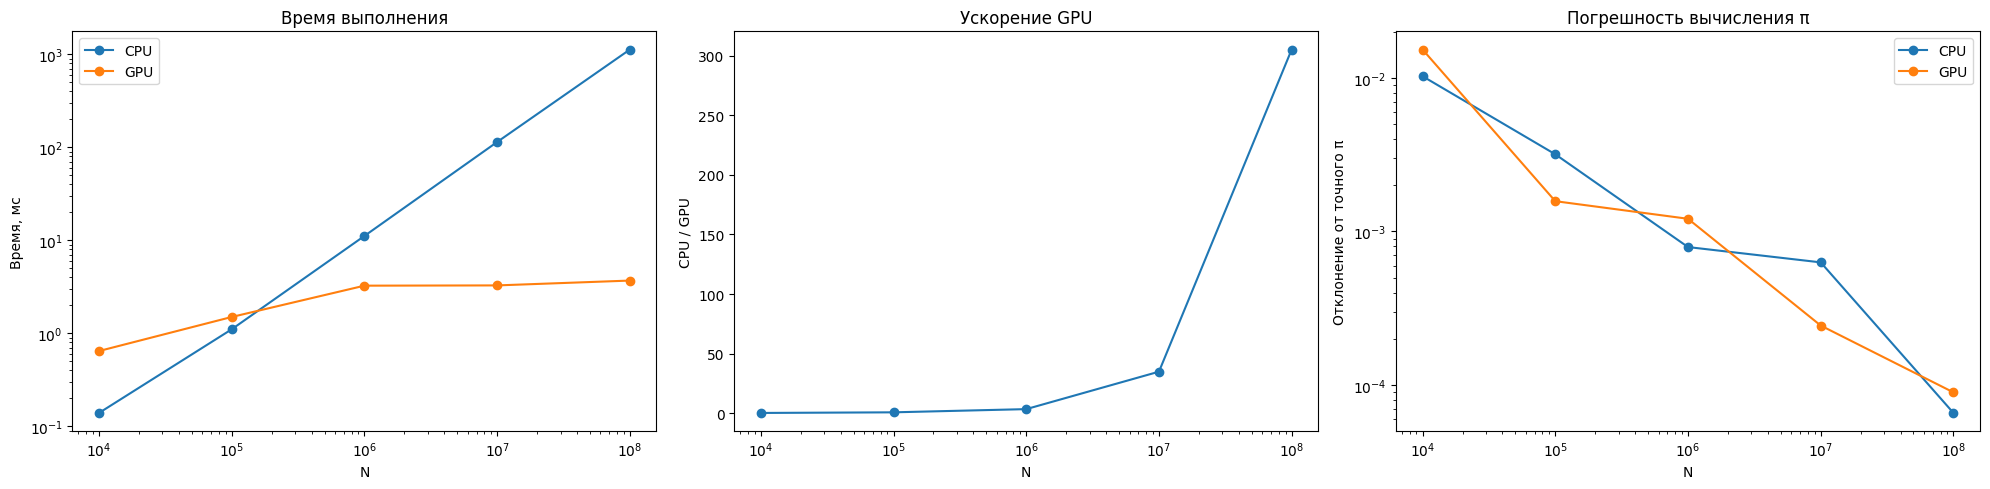

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(results_df["N"], results_df["CPU, мс"], marker="o", label="CPU")
axes[0].plot(results_df["N"], results_df["GPU, мс"], marker="o", label="GPU")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("N")
axes[0].set_ylabel("Время, мс")
axes[0].set_title("Время выполнения")
axes[0].legend()

axes[1].plot(results_df["N"], results_df["Ускорение"], marker="o")
axes[1].set_xscale("log")
axes[1].set_xlabel("N")
axes[1].set_ylabel("CPU / GPU")
axes[1].set_title("Ускорение GPU")

axes[2].plot(results_df["N"], results_df["Ошибка CPU"].replace(0, np.nan), marker="o", label="CPU")
axes[2].plot(results_df["N"], results_df["Ошибка GPU"].replace(0, np.nan), marker="o", label="GPU")
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel("N")
axes[2].set_ylabel("Отклонение от точного π")
axes[2].set_title("Погрешность вычисления π")
axes[2].legend()

for ax in axes:
    ax.grid(False)

plt.tight_layout()
plt.show()

## Вывод

В ходе лабораторной работы было выполнено вычисление числа π методом Монте-Карло на CPU и GPU. Результаты показали, что при небольшом количестве точек CPU работает быстрее, так как запуск GPU имеет дополнительные накладные расходы. Поэтому для малых значений N использование GPU не даёт преимущества.

При увеличении количества точек GPU начинает работать значительно эффективнее. Начиная примерно с N = 1 000 000, параллельная обработка на CUDA-потоках даёт заметное ускорение, а при N = 100 000 000 GPU выполняет расчёт примерно в 305 раз быстрее CPU. Это подтверждается графиками времени выполнения и ускорения: время CPU растёт намного быстрее, чем время GPU.

Также по графику погрешности видно, что с ростом N вычисленное значение Pi становится ближе к точному. Небольшие отличия между результатами CPU и GPU являются нормальными, так как метод Монте-Карло основан на случайной генерации точек. В итоге можно сделать вывод, что CPU удобнее для малых объёмов данных, а GPU значительно эффективнее при большом числе точек.